# Part 1.1: Piecewise Regression

In [94]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, f_regression
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import (
    r2_score, mean_absolute_error, root_mean_squared_error,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from scipy.spatial.distance import cdist

## Data Preprocessing

In [95]:
# Load data
wb_df = pd.read_csv('data/worldbank_2017_2021.csv')
regions_df = pd.read_excel('data/countries_regions.xlsx')

# Name mapping
name_map = {
    'United States': 'United States of America',
    'Viet Nam': 'Vietnam'
}
wb_df['Country Name'] = wb_df['Country Name'].replace(name_map)

# Drop >50% missing, impute, clip 
missing_pct = wb_df.isna().mean()
wb_df = wb_df.drop(columns=missing_pct[missing_pct > 0.5].index.tolist())
num_cols = [c for c in wb_df.select_dtypes(include=['float64', 'int64']).columns if c != 'Year']
for col in num_cols:
    wb_df[col] = wb_df[col].fillna(wb_df[col].median())
    wb_df[col] = wb_df[col].clip(wb_df[col].quantile(0.01), wb_df[col].quantile(0.99))

# Merge
df = wb_df.merge(regions_df, left_on='Country Name', right_on='CountryName', how='inner').drop(columns=['CountryName'])

# Target
target_col = 'GNI per capita, PPP (current international $)'
df = df.dropna(subset=[target_col])
feature_cols = [c for c in num_cols if c != target_col]

print(f'Samples: {len(df)}, Features: {len(feature_cols)}')

Samples: 1080, Features: 116


In [96]:
# Split test using year
train_df = df[df['Year'] < 2021].copy()
test_df = df[df['Year'] == 2021].copy()

y_train = train_df[target_col].values
y_test = test_df[target_col].values

print(f'Train (2017-2020): {len(train_df)}')
print(f'Test (2021): {len(test_df)}')

Train (2017-2020): 864
Test (2021): 216


---

# Baseline: Correlation + Lasso + Random Forest

Same as Project 1 part2.2

## Feature Selection

### Correlation Filter

In [97]:
corr = train_df[feature_cols].corrwith(train_df[target_col]).abs()
w2_corr_features = corr[corr >= 0.3].index.tolist()
print(f'After Correlation Filter: {len(w2_corr_features)} features')

After Correlation Filter: 50 features


### Lasso Feature Selection

In [98]:
X_train_corr2 = train_df[w2_corr_features].values
scaler2 = StandardScaler()
X_train_corr2_scaled = scaler2.fit_transform(X_train_corr2)

lasso = Lasso(alpha=100, max_iter=10000)
lasso.fit(X_train_corr2_scaled, y_train)
w2_lasso_features = [f for f, c in zip(w2_corr_features, lasso.coef_) if c != 0]
print(f'After Lasso Selection: {len(w2_lasso_features)} features')

After Lasso Selection: 38 features


## Modeling

### Random Forest

In [99]:
X_train_w2 = train_df[w2_lasso_features].values
X_test_w2 = test_df[w2_lasso_features].values

scaler_w2 = StandardScaler()
X_train_w2_scaled = scaler_w2.fit_transform(X_train_w2)
X_test_w2_scaled = scaler_w2.transform(X_test_w2)

rf_baseline = RandomForestRegressor(n_estimators=100, random_state=23)
rf_baseline.fit(X_train_w2_scaled, y_train)
y_pred_baseline = rf_baseline.predict(X_test_w2_scaled)

## Evaluation

In [100]:
w2_results = {
    'R2': r2_score(y_test, y_pred_baseline),
    'RMSE': root_mean_squared_error(y_test, y_pred_baseline),
    'MAE': mean_absolute_error(y_test, y_pred_baseline)
}

print(f'R2:   {w2_results["R2"]:.6f}')
print(f'RMSE: {w2_results["RMSE"]:.2f}')
print(f'MAE:  {w2_results["MAE"]:.2f}')

R2:   0.934867
RMSE: 5727.06
MAE:  3371.76


---

# Piecewise Regression

## Clustering Feature Selection

In [101]:
country_avg = train_df[['Country Name'] + feature_cols].groupby('Country Name').mean().reset_index()
print(f'Countries (from train): {len(country_avg)}')

X_country = country_avg[feature_cols].copy()

Countries (from train): 216


In [102]:
# VarianceThreshold
def remove_low_variance(df_in, threshold=0.01):
    selector = VarianceThreshold(threshold=threshold)
    arr = selector.fit_transform(df_in)
    kept = df_in.columns[selector.get_support()].tolist()
    return pd.DataFrame(arr, columns=kept, index=df_in.index), kept

scaler_vt = StandardScaler()
X_scaled_vt = pd.DataFrame(scaler_vt.fit_transform(X_country), columns=feature_cols, index=X_country.index)
X_vt, vt_kept = remove_low_variance(X_scaled_vt, threshold=0.01)
print(f'After VarianceThreshold: {len(vt_kept)} (from {len(feature_cols)})')

# Correlation filter >0.9
corr_matrix = X_vt.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
cluster_features = [c for c in vt_kept if c not in to_drop]
print(f'After corr filter (>0.9): {len(cluster_features)} (dropped {len(to_drop)})')

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_country[cluster_features])
print(f'Clustering input: {X_cluster_scaled.shape}')

After VarianceThreshold: 116 (from 116)
After corr filter (>0.9): 98 (dropped 18)
Clustering input: (216, 98)


## Determine k

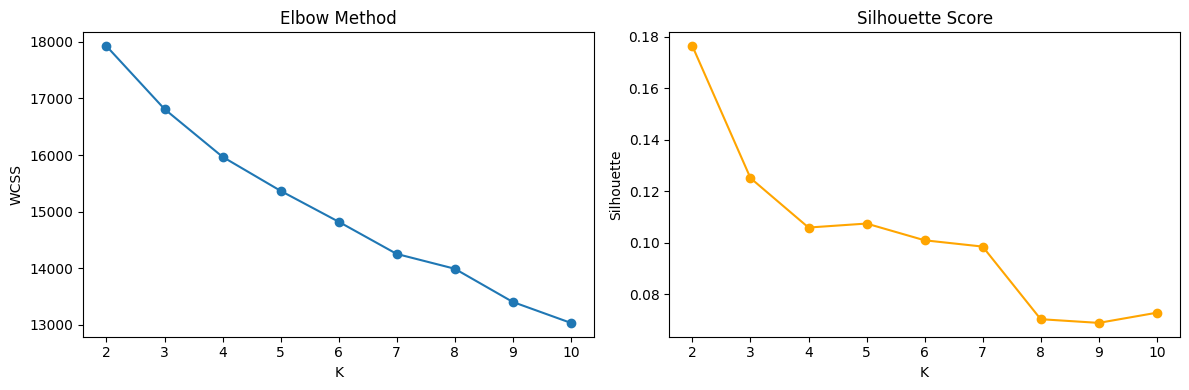

In [103]:
# Elbow + Silhouette
wcss = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=23)
    labels = kmeans.fit_predict(X_cluster_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, wcss, marker='o')
axes[0].set_xlabel('K'); axes[0].set_ylabel('WCSS'); axes[0].set_title('Elbow Method')
axes[1].plot(k_range, sil_scores, marker='o', color='orange')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette Score')
plt.tight_layout()
plt.show()

In [104]:
# Evaluation metrics for each k
def dunn_index(X, labels):
    unique_clusters = np.unique(labels)
    centroids = np.array([X[labels == k].mean(axis=0) for k in unique_clusters])
    inter_cluster_dist = np.min(
        cdist(centroids, centroids)[np.triu_indices(len(unique_clusters), k=1)]
    )
    intra_cluster_dist = max(
        np.max(cdist(X[labels == k], X[labels == k]))
        for k in unique_clusters
    )
    return inter_cluster_dist / intra_cluster_dist

def evaluate_clustering(X, X_clusters):
    silhouette = silhouette_score(X, X_clusters)
    db = davies_bouldin_score(X, X_clusters)
    dunn = dunn_index(X, X_clusters)
    ch = calinski_harabasz_score(X, X_clusters)
    return silhouette, db, dunn, ch

eval_rows = []
for k in k_range:
    km_tmp = KMeans(n_clusters=k, n_init=10, random_state=23)
    lbl_tmp = km_tmp.fit_predict(X_cluster_scaled)
    s, d, du, c = evaluate_clustering(X_cluster_scaled, lbl_tmp)
    eval_rows.append({'k': k, 'Silhouette': round(s, 4), 'Davies-Bouldin': round(d, 4),
                      'Dunn': round(du, 4), 'Calinski-Harabasz': round(c, 2)})

eval_df = pd.DataFrame(eval_rows)
print(eval_df.to_string(index=False))

 k  Silhouette  Davies-Bouldin   Dunn  Calinski-Harabasz
 2      0.1764          2.1105 0.3185              38.74
 3      0.1252          2.3457 0.3088              27.60
 4      0.1059          2.1914 0.2619              23.02
 5      0.1075          2.3970 0.2497              19.92
 6      0.1010          2.0879 0.2933              17.99
 7      0.0985          2.4454 0.2385              16.90
 8      0.0703          2.1749 0.2292              15.25
 9      0.0689          2.3412 0.2190              14.99
10      0.0728          2.1553 0.2403              14.29


In [105]:
best_k = 5

kmeans_model = KMeans(n_clusters=best_k, n_init=10, random_state=23,)
kmeans_labels = kmeans_model.fit_predict(X_cluster_scaled)
country_avg['Cluster'] = kmeans_labels

sil, db, dunn_val, ch = evaluate_clustering(X_cluster_scaled, kmeans_labels)
print(f'k={best_k}: Silhouette={sil:.4f}, DB={db:.4f}, Dunn={dunn_val:.4f}, CH={ch:.2f}')
print(f'\nCluster distribution:')
print(country_avg['Cluster'].value_counts().sort_index())

k=5: Silhouette=0.1075, DB=2.3970, Dunn=0.2497, CH=19.92

Cluster distribution:
Cluster
0    12
1    95
2    41
3    58
4    10
Name: count, dtype: int64


## Cluster Visualizations

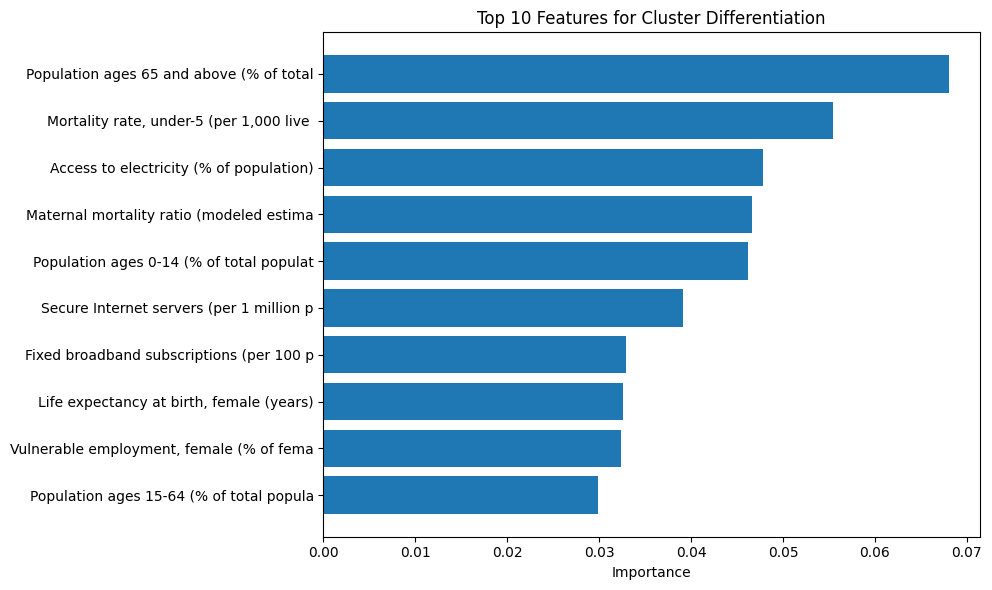

In [106]:
# RF feature importance
rf_clf = RandomForestClassifier(n_estimators=100, random_state=23)
rf_clf.fit(X_cluster_scaled, kmeans_labels)

feature_importance_cl = pd.DataFrame({
    'Feature': cluster_features,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

top_10_features = feature_importance_cl.head(10)['Feature'].tolist()

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_cl.head(10)['Feature'].str[:40], feature_importance_cl.head(10)['Importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features for Cluster Differentiation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

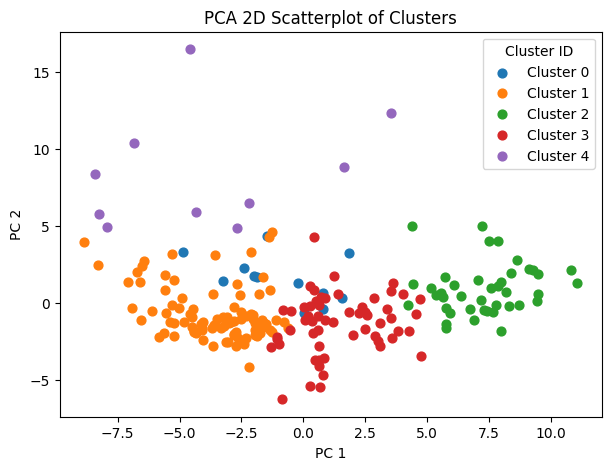

In [107]:
# PCA 2D scatter
def create_pca_scatterplot(X_scaled, X_clusters):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    plt.figure(figsize=(7, 5))
    for cluster_id in np.unique(X_clusters):
        idx = X_clusters == cluster_id
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], s=40, label=f'Cluster {cluster_id}')
    plt.title('PCA 2D Scatterplot of Clusters')
    plt.xlabel('PC 1'); plt.ylabel('PC 2')
    plt.legend(title='Cluster ID')
    plt.show()

create_pca_scatterplot(X_cluster_scaled, kmeans_labels)

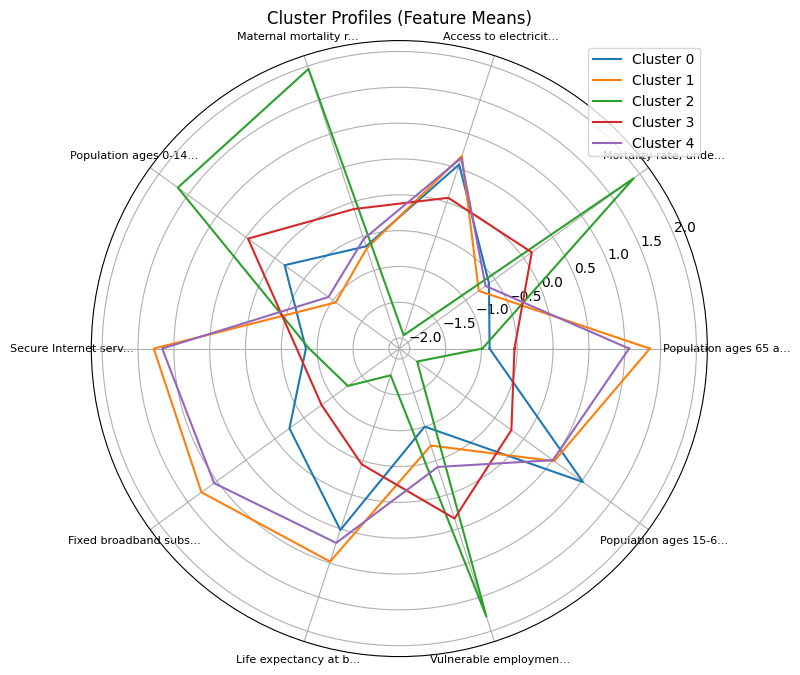

In [108]:
# Radar chart
def create_radar_graph(X, X_clusters):
    clustered_df = X.copy()
    clustered_df['Cluster'] = X_clusters
    cluster_means = clustered_df.groupby('Cluster').mean()
    labels = cluster_means.columns
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]
    plt.figure(figsize=(8, 8))
    for i, row in cluster_means.iterrows():
        values = row.tolist() + row.tolist()[:1]
        plt.polar(angles, values, label=f'Cluster {i}')
    plt.xticks(angles[:-1], labels, fontsize=8)
    plt.title('Cluster Profiles (Feature Means)')
    plt.legend()
    plt.show()

cluster_means_raw = pd.DataFrame(X_cluster_scaled, columns=cluster_features)
cluster_means_raw['KMeans_Cluster'] = kmeans_labels
cluster_means_raw = cluster_means_raw.groupby('KMeans_Cluster')[top_10_features].mean()
scaler_radar = StandardScaler()
X_top10_scaled = pd.DataFrame(
    scaler_radar.fit_transform(cluster_means_raw),
    columns=cluster_means_raw.columns, index=cluster_means_raw.index
)
X_top10_scaled.columns = [c[:20] + '...' if len(c) > 20 else c for c in X_top10_scaled.columns]
create_radar_graph(X_top10_scaled, X_top10_scaled.index.values)

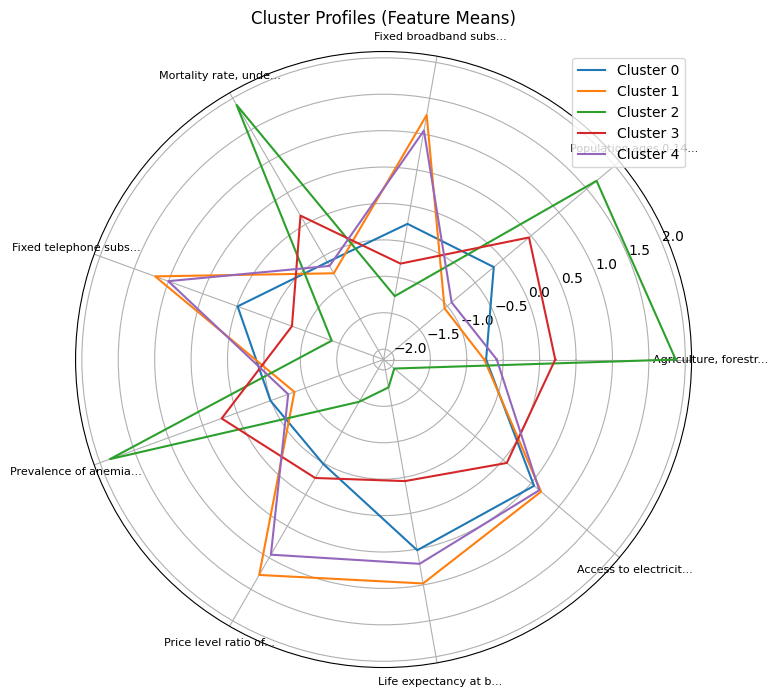

In [131]:
radar_features = ['Agriculture, forestry, and fishing, value added (% of GDP)',
 'Population ages 0-14 (% of total population)',
 'Fixed broadband subscriptions (per 100 people)',
 'Mortality rate, under-5 (per 1,000 live births)',
 'Fixed telephone subscriptions (per 100 people)',
 'Prevalence of anemia among children (% of children ages 6-59 months)',
 'Life expectancy at birth, total (years)',
 'Price level ratio of PPP conversion factor (GDP) to market exchange rate',
 'Life expectancy at birth, female (years)',
 'Access to electricity (% of population)']                                                                                                                                                                            

available = [f for f in radar_features if f in cluster_features]                                                                                                                    
cluster_means_raw2 = pd.DataFrame(X_cluster_scaled, columns=cluster_features)                                                                                                    
cluster_means_raw2['KMeans_Cluster'] = kmeans_labels                                                                                                                             
cluster_means_raw2 = cluster_means_raw2.groupby('KMeans_Cluster')[available].mean()                                                                                                
scaler_radar2 = StandardScaler()
X_desc_scaled = pd.DataFrame(                                                                                                                                                          
    scaler_radar2.fit_transform(cluster_means_raw2),                                                                                                                             
    columns=cluster_means_raw2.columns, index=cluster_means_raw2.index                                                                                                           
)                                                                                                                                                                                  
X_desc_scaled.columns = [c[:20] + '...' if len(c) > 20 else c for c in X_desc_scaled.columns]
create_radar_graph(X_desc_scaled, X_desc_scaled.index.values)    

In [132]:
[f for f in radar_features if f not in available]

['Life expectancy at birth, total (years)']

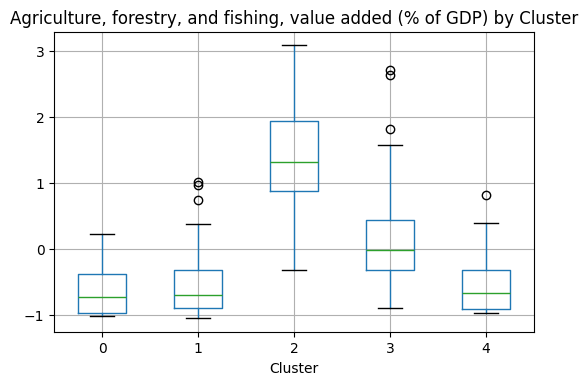

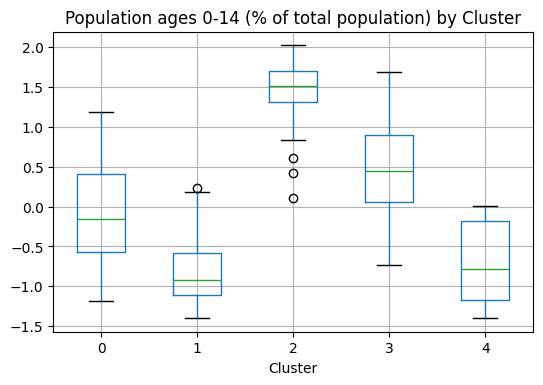

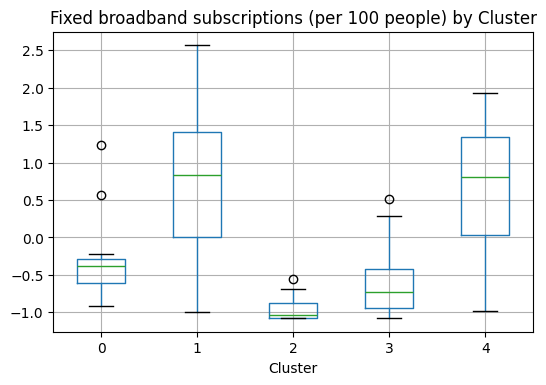

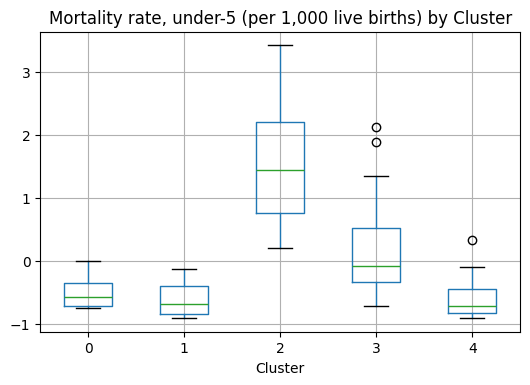

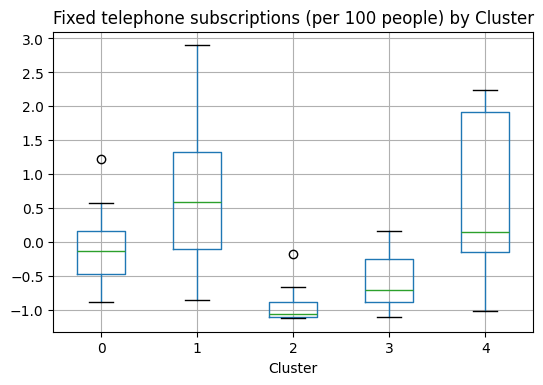

In [134]:
# Boxplots
def create_feature_boxplots(X, X_clusters):
    clustered_df = X.copy()
    clustered_df['Cluster'] = X_clusters
    for col in X.columns:
        clustered_df.boxplot(column=col, by='Cluster', figsize=(6, 4))
        plt.title(f'{col} by Cluster')
        plt.suptitle('')
        plt.show()

X_top5 = pd.DataFrame(X_cluster_scaled, columns=cluster_features)[radar_features[:5]].copy()
create_feature_boxplots(X_top5, kmeans_labels)

## Cluster Labeling

In [110]:
# Map cluster labels to traindf
cluster_map = country_avg.set_index('Country Name')['Cluster'].to_dict()
train_df['Cluster'] = train_df['Country Name'].map(cluster_map)

print('Train clusters:')
print(train_df['Cluster'].value_counts().sort_index())

Train clusters:
Cluster
0     48
1    380
2    164
3    232
4     40
Name: count, dtype: int64


## Per-Cluster IQR Clipping

In [111]:
# IQR clipping on TRAIN only
cluster_gni_std = train_df.groupby('Cluster')[target_col].std()
median_std = cluster_gni_std.median()
print('GNI std per cluster:')
print(cluster_gni_std.round(0))

for cid in sorted(train_df['Cluster'].unique()):
    c_train = train_df['Cluster'] == cid
    mult = 1.0 if cluster_gni_std.get(cid, 0) > median_std else 1.5
    clipped = 0

    for col in feature_cols:
        Q1 = train_df.loc[c_train, col].quantile(0.25)
        Q3 = train_df.loc[c_train, col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - mult * IQR, Q3 + mult * IQR
        clipped += ((train_df.loc[c_train, col] < lo) | (train_df.loc[c_train, col] > hi)).sum()
        train_df.loc[c_train, col] = train_df.loc[c_train, col].clip(lo, hi)

    print(f'Cluster {cid}: {clipped} train cells clipped (n_train={c_train.sum()})')

GNI std per cluster:
Cluster
0    26217.0
1    20125.0
2     3301.0
3     5058.0
4    19561.0
Name: GNI per capita, PPP (current international $), dtype: float64
Cluster 0: 678 train cells clipped (n_train=48)
Cluster 1: 6056 train cells clipped (n_train=380)
Cluster 2: 1284 train cells clipped (n_train=164)
Cluster 3: 2276 train cells clipped (n_train=232)
Cluster 4: 248 train cells clipped (n_train=40)


## Multicollinearity Test (VIF) per Cluster

In [112]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

corr_threshold = 0.3

for cid in sorted(train_df["Cluster"].unique()):
    c_mask = train_df["Cluster"] == cid
    X_c = train_df.loc[c_mask, feature_cols]
    y_c = train_df.loc[c_mask, target_col]

    # Correlation filter (same as Lasso pipeline)
    c_corr = X_c.corrwith(y_c).abs().dropna()
    c_corr_feats = c_corr[c_corr >= corr_threshold].index.tolist()

    scaler_vif = StandardScaler()
    X_scaled = scaler_vif.fit_transform(X_c[c_corr_feats])

    vif_data = pd.DataFrame({
        "Feature": c_corr_feats,
        "VIF": [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
    }).sort_values("VIF", ascending=False)

    high_vif = (vif_data["VIF"] > 10).sum()
    max_vif = vif_data["VIF"].max()
    print(f"Cluster {cid}: {len(c_corr_feats)} corr features, "
          f"{high_vif} with VIF>10 (max VIF={max_vif:.1f})")
    print(vif_data.head(5).to_string(index=False))
    print()


Cluster 0: 79 corr features, 79 with VIF>10 (max VIF=inf)
                                                                 Feature          VIF
                                 Access to electricity (% of population)          inf
                                            Arable land (% of land area) 1.201275e+07
Risk of catastrophic expenditure for surgical care (% of people at risk) 9.501356e+06
                              Current account balance (BoP, current US$) 7.665052e+06
                        Prevalence of undernourishment (% of population) 7.631912e+06

Cluster 1: 43 corr features, 15 with VIF>10 (max VIF=58061889.0)
                                 Feature          VIF
Urban population (% of total population) 5.806189e+07
Rural population (% of total population) 5.806177e+07
 Life expectancy at birth, total (years) 4.153901e+03
  Life expectancy at birth, male (years) 1.504409e+03
Life expectancy at birth, female (years) 7.686013e+02

Cluster 2: 9 corr features, 0 with 

## Per-Cluster Model Training

In [113]:
LASSO_ALPHAS = [0.1, 1, 10, 50, 100, 500, 1000]

cluster_models = {}
cluster_selected_features = {}
fallback_clusters = []

def lasso_feature_select(X_c_all, y_c, feature_cols, corr_threshold=0.3, max_feat_pct=0.20):
    """Correlation filter + Lasso GridSearchCV feature selection.
    Returns list of selected feature names.
    """
    n_train = len(X_c_all)
    cv_folds = min(5, n_train // 2)

    # Correlation filter
    c_corr = X_c_all[feature_cols].corrwith(pd.Series(y_c, index=X_c_all.index)).abs().dropna()
    c_corr_feats = c_corr[c_corr >= corr_threshold].index.tolist()

    # Lasso with GridSearchCV
    scaler_lasso = StandardScaler()
    X_lasso = scaler_lasso.fit_transform(X_c_all[c_corr_feats].values)

    lasso_grid = GridSearchCV(
        Lasso(max_iter=10000, random_state=23),
        param_grid={'alpha': LASSO_ALPHAS},
        scoring='r2', cv=cv_folds
    )
    lasso_grid.fit(X_lasso, y_c)
    best_alpha = lasso_grid.best_params_['alpha']
    best_lasso = lasso_grid.best_estimator_

    c_selected = [f for f, c in zip(c_corr_feats, best_lasso.coef_) if c != 0]

    # Cap features
    max_feats = max(3, int(n_train * max_feat_pct))
    if len(c_selected) > max_feats:
        feat_coef = [(f, abs(c)) for f, c in zip(c_corr_feats, best_lasso.coef_) if c != 0]
        feat_coef.sort(key=lambda x: x[1], reverse=True)
        c_selected = [f for f, _ in feat_coef[:max_feats]]

    if len(c_selected) < 3:
        c_selected = c_corr.nlargest(min(10, len(c_corr_feats))).index.tolist()

    return c_selected, c_corr_feats, best_alpha, max_feats

### Cluster 0 regression (lower developed coutries)

In [114]:
cid = 0
c_mask = train_df['Cluster'] == cid
X_c_all = train_df.loc[c_mask, feature_cols]
y_c = train_df.loc[c_mask, target_col].values
n_train = len(X_c_all)
cv_folds = 5

# Lasso feature selection
c_selected, c_corr_feats, best_alpha, max_feats = lasso_feature_select(
    X_c_all, y_c, feature_cols, corr_threshold=0.3, max_feat_pct=0.20
)
print(f'Cluster {cid}: n={n_train}, feat_select=lasso, corr_feats={len(c_corr_feats)}, '
      f'lasso_alpha={best_alpha}, selected={len(c_selected)} (cap=20%={max_feats})')

cluster_selected_features[cid] = c_selected

# RandomizedSearchCV for RF
param_dist_0 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2, 4]
}
X_c_train = X_c_all[c_selected].values
n_iter = min(20, n_train)

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=23),
    param_distributions=param_dist_0,
    n_iter=n_iter,
    scoring='r2',
    cv=cv_folds,
    n_jobs=-1,
    random_state=23
)
search.fit(X_c_train, y_c)

cluster_models[cid] = search.best_estimator_
bp = search.best_params_
print(f'  cv_R2={search.best_score_:.3f}, n_estimators={bp["n_estimators"]}, max_depth={bp["max_depth"]}, '
      f'min_samples_split={bp["min_samples_split"]}, min_samples_leaf={bp["min_samples_leaf"]}, ')
print(f'  Selected:\n    ' + '\n    '.join([f[:40] for f in c_selected]))

Cluster 0: n=48, feat_select=lasso, corr_feats=79, lasso_alpha=100, selected=9 (cap=20%=9)
  cv_R2=0.960, n_estimators=100, max_depth=5, min_samples_split=2, min_samples_leaf=1, 
  Selected:
    Labor force participation rate, female (
    Population ages 65 and above (% of total
    Birth rate, crude (per 1,000 people)
    Adjusted net savings, including particul
    Air transport, registered carrier depart
    Mortality caused by road traffic injury 
    Inflation, consumer prices (annual %)
    Cereal yield (kg per hectare)
    Livestock production index (2014-2016 = 


### Cluster 1 regression (upper developed countries)

In [115]:
cid = 1
c_mask = train_df['Cluster'] == cid
X_c_all = train_df.loc[c_mask, feature_cols]
y_c = train_df.loc[c_mask, target_col].values
n_train = len(X_c_all)
cv_folds = 5

# Lasso feature selection
c_selected, c_corr_feats, best_alpha, max_feats = lasso_feature_select(
    X_c_all, y_c, feature_cols, corr_threshold=0.3, max_feat_pct=0.20
)
print(f'Cluster {cid}: n={n_train}, feat_select=lasso, corr_feats={len(c_corr_feats)}, '
      f'lasso_alpha={best_alpha}, selected={len(c_selected)} (cap=20%={max_feats})')

cluster_selected_features[cid] = c_selected

# RandomizedSearchCV for RF
param_dist_1 = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
X_c_train = X_c_all[c_selected].values
n_iter = min(20, n_train)

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=23),
    param_distributions=param_dist_1,
    n_iter=n_iter,
    scoring='r2',
    cv=cv_folds,
    n_jobs=-1,
    random_state=23
)
search.fit(X_c_train, y_c)

cluster_models[cid] = search.best_estimator_
bp = search.best_params_
print(f'  cv_R2={search.best_score_:.3f}, n_estimators={bp["n_estimators"]}, max_depth={bp["max_depth"]}, '
      f'min_samples_split={bp["min_samples_split"]}, min_samples_leaf={bp["min_samples_leaf"]}, ')
print(f'  Selected:\n    ' + '\n    '.join([f[:40] for f in c_selected]))

Cluster 1: n=380, feat_select=lasso, corr_feats=43, lasso_alpha=50, selected=36 (cap=20%=76)
  cv_R2=0.949, n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1, 
  Selected:
    Agriculture, forestry, and fishing, valu
    Permanent cropland (% of land area)
    Rural population (% of total population)
    Mortality rate, under-5 (per 1,000 live 
    Population growth (annual %)
    Urban population (% of total population)
    Adjusted net savings, including particul
    Current account balance (BoP, current US
    Exports of goods and services (% of GDP)
    Gross savings (% of GDP)
    Inflation, consumer prices (annual %)
    Medium and high-tech manufacturing value
    Price level ratio of PPP conversion fact
    Total reserves (includes gold, current U
    Children out of school, primary, female
    Population ages 0-14 (% of total populat
    Unemployment, total (% of total labor fo
    Energy intensity level of primary energy
    Air transport, registered c

### Cluster 2 regression (least developed countries)

In [116]:
cid = 2
c_mask = train_df['Cluster'] == cid
X_c_all = train_df.loc[c_mask, feature_cols]
y_c = train_df.loc[c_mask, target_col].values
n_train = len(X_c_all)
cv_folds = 5
max_feat_pct = 0.20
f_top_n = 10
scaler_f = StandardScaler()
X_f_scaled = scaler_f.fit_transform(X_c_all[feature_cols].values)
f_scores, p_values = f_regression(X_f_scaled, y_c)
feat_f_df = pd.DataFrame({
    'feature': feature_cols, 'f_score': f_scores, 'p_value': p_values
}).sort_values('f_score', ascending=False)

n_select = min(f_top_n, max(3, int(n_train * max_feat_pct)))
c_selected = feat_f_df.head(n_select)['feature'].tolist()

print(f'Cluster {cid}: n={n_train}, feat_select=f_regression, '
      f'selected={len(c_selected)} (top {n_select})')

cluster_selected_features[cid] = c_selected


# RandomizedSearchCV for RF
param_dist_2 = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
X_c_train = X_c_all[c_selected].values
n_iter = min(20, n_train)

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=23),
    param_distributions=param_dist_2,
    n_iter=n_iter,
    scoring='r2',
    cv=cv_folds,
    n_jobs=-1,
    random_state=23
)
search.fit(X_c_train, y_c)

cluster_models[cid] = search.best_estimator_
bp = search.best_params_
print(f'  cv_R2={search.best_score_:.3f}, n_estimators={bp["n_estimators"]}, max_depth={bp["max_depth"]}, '
      f'min_samples_split={bp["min_samples_split"]}, min_samples_leaf={bp["min_samples_leaf"]}, ')
print(f'  Selected:\n    ' + '\n    '.join([f[:40] for f in c_selected]))

Cluster 2: n=164, feat_select=f_regression, selected=10 (top 10)
  cv_R2=0.876, n_estimators=200, max_depth=None, min_samples_split=2, min_samples_leaf=1, 
  Selected:
    Agriculture, forestry, and fishing, valu
    Renewable energy consumption (% of total
    Population growth (annual %)
    Unemployment, total (% of total labor fo
    High-technology exports (current US$)
    Net ODA received (% of GNI)
    Fixed telephone subscriptions (per 100 p
    Energy intensity level of primary energy
    Birth rate, crude (per 1,000 people)
    Strength of legal rights index (0=weak t


### Cluster 3 regression (developing coutries)

In [117]:
cid = 3
c_mask = train_df['Cluster'] == cid
X_c_all = train_df.loc[c_mask, feature_cols]
y_c = train_df.loc[c_mask, target_col].values
n_train = len(X_c_all)
cv_folds = 5

# f_regression feature selection
max_feat_pct = 0.20
f_top_n = 10
scaler_f = StandardScaler()
X_f_scaled = scaler_f.fit_transform(X_c_all[feature_cols].values)
f_scores, p_values = f_regression(X_f_scaled, y_c)
feat_f_df = pd.DataFrame({
    'feature': feature_cols, 'f_score': f_scores, 'p_value': p_values
}).sort_values('f_score', ascending=False)

n_select = min(f_top_n, max(3, int(n_train * max_feat_pct)))
c_selected = feat_f_df.head(n_select)['feature'].tolist()

print(f'Cluster {cid}: n={n_train}, feat_select=f_regression, '
      f'selected={len(c_selected)} (top {n_select})')

cluster_selected_features[cid] = c_selected

# RandomizedSearchCV for RF
param_dist_3 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
} 
X_c_train = X_c_all[c_selected].values
n_iter = min(20, n_train)

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=23),
    param_distributions=param_dist_3,
    n_iter=n_iter,
    scoring='r2',
    cv=cv_folds,
    n_jobs=-1,
    random_state=23
)
search.fit(X_c_train, y_c)

cluster_models[cid] = search.best_estimator_
bp = search.best_params_
print(f'  cv_R2={search.best_score_:.3f}, n_estimators={bp["n_estimators"]}, max_depth={bp["max_depth"]}, '
      f'min_samples_split={bp["min_samples_split"]}, min_samples_leaf={bp["min_samples_leaf"]}, ')
print(f'  Selected:\n    ' + '\n    '.join([f[:40] for f in c_selected]))

Cluster 3: n=232, feat_select=f_regression, selected=10 (top 10)
  cv_R2=0.831, n_estimators=100, max_depth=7, min_samples_split=2, min_samples_leaf=1, 
  Selected:
    Population ages 0-14 (% of total populat
    Fixed broadband subscriptions (per 100 p
    Age dependency ratio (% of working-age p
    Population ages 15-64 (% of total popula
    Population ages 65 and above (% of total
    Net ODA received (% of GNI)
    Birth rate, crude (per 1,000 people)
    Agriculture, forestry, and fishing, valu
    Fertility rate, total (births per woman)
    Fixed telephone subscriptions (per 100 p


### Cluster 4 regression (developing coutries)

In [118]:
cid = 4
c_mask = train_df['Cluster'] == cid
X_c_all = train_df.loc[c_mask, feature_cols]
y_c = train_df.loc[c_mask, target_col].values
n_train = len(X_c_all)
cv_folds = 5

# Lasso feature selection
c_selected, c_corr_feats, best_alpha, max_feats = lasso_feature_select(
    X_c_all, y_c, feature_cols, corr_threshold=0.3, max_feat_pct=0.20
)
print(f'Cluster {cid}: n={n_train}, feat_select=lasso, corr_feats={len(c_corr_feats)}, '
      f'lasso_alpha={best_alpha}, selected={len(c_selected)} (cap=20%={max_feats})')

cluster_selected_features[cid] = c_selected

# RandomizedSearchCV for RF
param_dist_4 = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4, 8]
}
X_c_train = X_c_all[c_selected].values
n_iter = min(20, n_train)

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=23),
    param_distributions=param_dist_4,
    n_iter=n_iter,
    scoring='r2',
    cv=cv_folds,
    n_jobs=-1,
    random_state=23
)
search.fit(X_c_train, y_c)

cluster_models[cid] = search.best_estimator_
bp = search.best_params_
print(f'  cv_R2={search.best_score_:.3f}, n_estimators={bp["n_estimators"]}, max_depth={bp["max_depth"]}, '
      f'min_samples_split={bp["min_samples_split"]}, min_samples_leaf={bp["min_samples_leaf"]}, ')
print(f'  Selected:\n    ' + '\n    '.join([f[:40] for f in c_selected]))

Cluster 4: n=40, feat_select=lasso, corr_feats=78, lasso_alpha=100, selected=8 (cap=20%=8)
  cv_R2=0.988, n_estimators=50, max_depth=10, min_samples_split=2, min_samples_leaf=2, 
  Selected:
    Secure Internet servers (per 1 million p
    External debt stocks, total (DOD, curren
    Merchandise imports (current US$)
    Technical cooperation grants (BoP, curre
    School enrollment, tertiary (% gross)
    Industry (including construction), value
    Renewable energy consumption (% of total
    External debt stocks (% of GNI)


## Prediction

In [119]:
X_test_cluster_feats = test_df[cluster_features].values
X_test_cluster_scaled = scaler_cluster.transform(X_test_cluster_feats)
test_df['Cluster'] = kmeans_model.predict(X_test_cluster_scaled)
all_test_cluster = sorted(test_df['Cluster'].unique())

print('Test clusters (kmeans-assigned):')
print(test_df['Cluster'].value_counts().sort_index())

y_pred_piecewise = np.full(len(test_df), np.nan)

for cid in all_test_cluster:
    t_mask = test_df['Cluster'] == cid

    c_feats = cluster_selected_features[cid]
    X_t = test_df.loc[t_mask, c_feats].values
    y_pred_piecewise[t_mask.values] = cluster_models[cid].predict(X_t)

Test clusters (kmeans-assigned):
Cluster
0    12
1    93
2    37
3    64
4    10
Name: count, dtype: int64


## Evaluation

In [120]:
# Per-cluster metrics
y_test_pw = y_test.copy()
rows = []
for cid in all_test_cluster:
    t_mask = test_df['Cluster'] == cid
    y_true_c = test_df.loc[t_mask, target_col].values
    y_pred_c = y_pred_piecewise[t_mask.values]
    n = t_mask.sum()
    n_feats = len(cluster_selected_features.get(cid, [])) 

    rows.append({'Cluster': cid, 'N_test': n, 'N_features': n_feats,
                    'R2': r2_score(y_true_c, y_pred_c),
                    'RMSE': root_mean_squared_error(y_true_c, y_pred_c),
                    'MAE': mean_absolute_error(y_true_c, y_pred_c),})
per_cluster_df = pd.DataFrame(rows)
print('Per-Cluster Metrics:')
print(per_cluster_df.to_string(index=False))

Per-Cluster Metrics:
 Cluster  N_test  N_features       R2        RMSE         MAE
       0      12           9 0.901353 8734.694498 5849.966455
       1      93          36 0.926343 6027.862816 4326.070398
       2      37          10 0.912095  870.719207  456.563243
       3      64          10 0.815555 2320.587876 1676.639285
       4      10           8 0.949836 4763.499410 3535.951008


In [121]:
# Overall piecewise metrics
valid = ~np.isnan(y_pred_piecewise)
pw_results = {
    'R2': r2_score(y_test_pw[valid], y_pred_piecewise[valid]),
    'RMSE': root_mean_squared_error(y_test_pw[valid], y_pred_piecewise[valid]),
    'MAE': mean_absolute_error(y_test_pw[valid], y_pred_piecewise[valid])
}
print(f'Overall Piecewise: R2={pw_results["R2"]:.6f}, RMSE={pw_results["RMSE"]:.2f}, MAE={pw_results["MAE"]:.2f}')

Overall Piecewise: R2=0.955004, RMSE=4760.13, MAE=2926.30


---

# Summarize

In [122]:
comparison = pd.DataFrame([
    {'Model': 'Baseline W2: Corr+Lasso+RF', 'R2': round(w2_results['R2'], 4),
     'RMSE': round(w2_results['RMSE'], 2), 'MAE': round(w2_results['MAE'], 2)},
    {'Model': f'Piecewise RF (k={best_k})', 'R2': round(pw_results['R2'], 4),
     'RMSE': round(pw_results['RMSE'], 2), 'MAE': round(pw_results['MAE'], 2)},
])
print(comparison.to_string(index=False))
print()
r2_imp = (pw_results['R2'] - w2_results['R2']) / abs(w2_results['R2']) * 100
rmse_imp = (w2_results['RMSE'] - pw_results['RMSE']) / w2_results['RMSE'] * 100
print(f'Piecewise improvement: R2 {r2_imp:+.1f}%, RMSE {rmse_imp:+.1f}%')

                     Model     R2    RMSE     MAE
Baseline W2: Corr+Lasso+RF 0.9349 5727.06 3371.76
        Piecewise RF (k=5) 0.9550 4760.13 2926.30

Piecewise improvement: R2 +2.2%, RMSE +16.9%


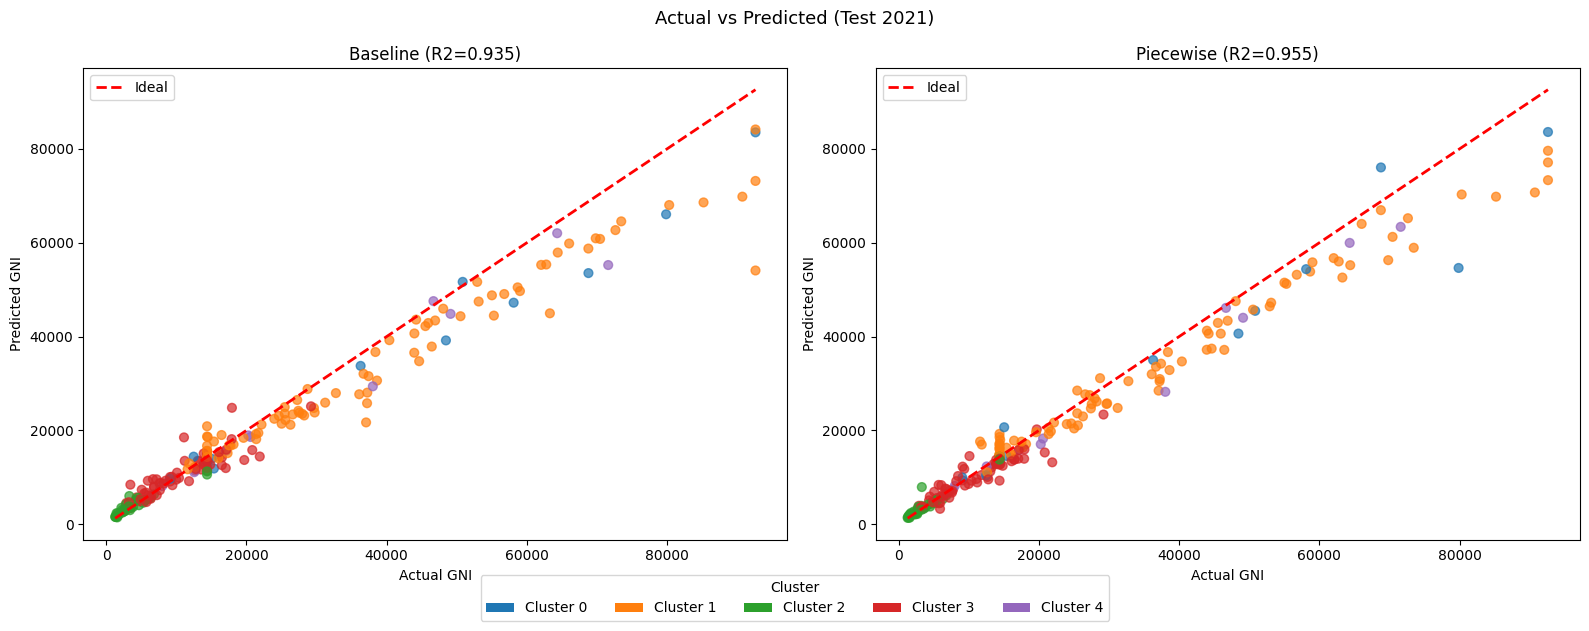

In [123]:
# Actual vs Predicted side-by-side
from matplotlib.patches import Patch

colors_map = {cid: plt.cm.tab10.colors[i] for i, cid in enumerate(all_test_cluster)}
point_colors = [colors_map[c] for c in test_df['Cluster'].values]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, y_pred, title in [
    (axes[0], y_pred_baseline, f'Baseline (R2={w2_results["R2"]:.3f})'),
    (axes[1], y_pred_piecewise, f'Piecewise (R2={pw_results["R2"]:.3f})'),
]:
    ax.scatter(y_test_pw, y_pred, c=point_colors, alpha=0.7, s=40)
    lo = min(y_test_pw.min(), y_pred.min())
    hi = max(y_test_pw.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Ideal')
    ax.set_xlabel('Actual GNI'); ax.set_ylabel('Predicted GNI')
    ax.set_title(title); ax.legend()

legend_el = [Patch(facecolor=colors_map[c], label=f'Cluster {c}') for c in all_test_cluster]
fig.legend(handles=legend_el, loc='lower center', ncol=len(all_test_cluster),
           bbox_to_anchor=(0.5, -0.05), title='Cluster')
plt.suptitle('Actual vs Predicted (Test 2021)', fontsize=13)
plt.tight_layout()
plt.show()

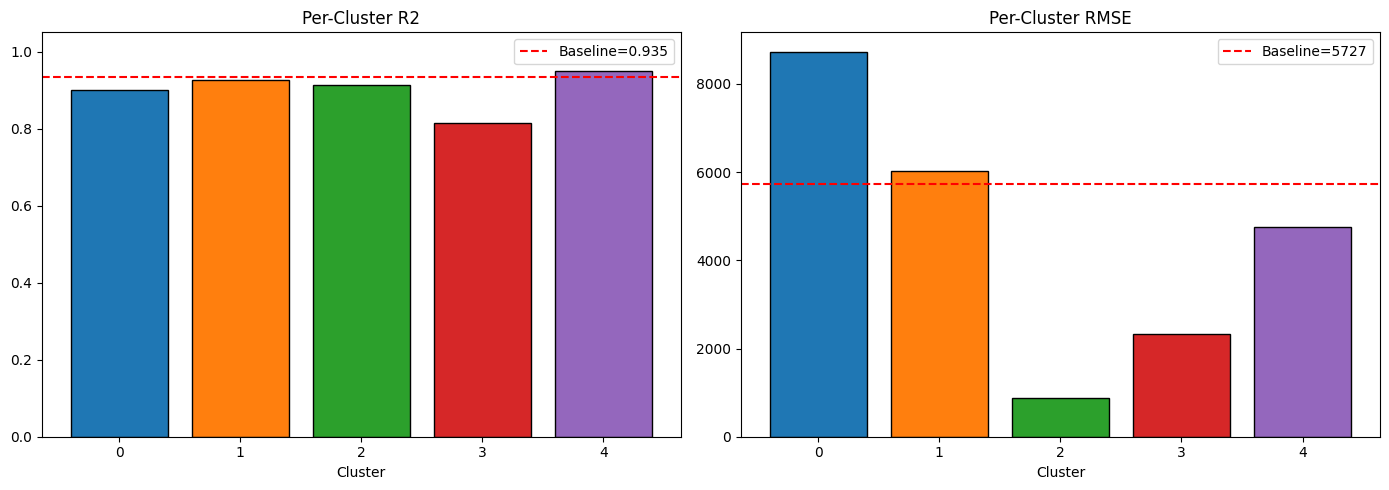

In [124]:
# Per-cluster R2 and RMSE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
valid_rows = per_cluster_df.dropna(subset=['R2'])
bar_c = [colors_map.get(c, 'gray') for c in valid_rows['Cluster']]

axes[0].bar(valid_rows['Cluster'].astype(str), valid_rows['R2'], color=bar_c, edgecolor='black')
axes[0].axhline(w2_results['R2'], color='red', linestyle='--', label=f'Baseline={w2_results["R2"]:.3f}')
axes[0].set_title('Per-Cluster R2'); axes[0].set_xlabel('Cluster')
axes[0].set_ylim(0, 1.05); axes[0].legend()

valid_r = per_cluster_df.dropna(subset=['RMSE'])
bar_r = [colors_map.get(c, 'gray') for c in valid_r['Cluster']]
axes[1].bar(valid_r['Cluster'].astype(str), valid_r['RMSE'], color=bar_r, edgecolor='black')
axes[1].axhline(w2_results['RMSE'], color='red', linestyle='--', label=f'Baseline={w2_results["RMSE"]:.0f}')
axes[1].set_title('Per-Cluster RMSE'); axes[1].set_xlabel('Cluster'); axes[1].legend()

plt.tight_layout()
plt.show()

In [125]:
print(comparison.to_string(index=False))
print()
print('Per-Cluster (kmeans-assigned):')
print(per_cluster_df.to_string(index=False))

                     Model     R2    RMSE     MAE
Baseline W2: Corr+Lasso+RF 0.9349 5727.06 3371.76
        Piecewise RF (k=5) 0.9550 4760.13 2926.30

Per-Cluster (kmeans-assigned):
 Cluster  N_test  N_features       R2        RMSE         MAE
       0      12           9 0.901353 8734.694498 5849.966455
       1      93          36 0.926343 6027.862816 4326.070398
       2      37          10 0.912095  870.719207  456.563243
       3      64          10 0.815555 2320.587876 1676.639285
       4      10           8 0.949836 4763.499410 3535.951008
